(03-14-roll)=

# Roll: de critique en de R²

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1977–1988.

**Wat we al weten.** Het CAPM uit [](#02-08-capm) zegt dat verwachte rendementen
lineair zijn in de bèta ten opzichte van de marktportefeuille, en de toetsen van
Black, Jensen, Scholes, Fama en MacBeth vonden een lijn die te vlak is. Ross bood
met de APT een alternatief zonder marktportefeuille ([](#03-11-apt-no-arbitrage)),
en de consumptiemodellen van [](#03-12-consumptie-capm) en
[](#03-13-equity-premium-puzzle) lieten zien dat de theorie van de discontovoet
zelf nog lang niet rond is. Maar niemand had nog gevraagd wat een toets van het
CAPM precies toetst — en hoeveel van de beweging van een koers we eigenlijk met
enig model begrijpen.

**Welke vraag staat open.** Kan het CAPM met een aandelenindex als marktportefeuille
überhaupt worden getoetst, en welk deel van de rendementen verklaren
systematische factoren?
```

## Overzicht

In maart 1977 publiceerde Richard Roll in de *Journal of Financial Economics* een
artikel van bijna vijftig pagina's dat de empirische literatuur over het CAPM in
één keer op een andere voet zette {cite}`Roll1977`. De stelling was niet dat het
CAPM onjuist is, maar dat de toetsen die men tot dan toe had uitgevoerd er niets
over zeiden. De lineaire relatie tussen verwacht rendement en bèta is volgens Roll
wiskundig equivalent met de uitspraak dat de gebruikte marktportefeuille
mean-variance-efficiënt is; de enige toetsbare hypothese van het model is dus de
efficiëntie van de *ware* marktportefeuille, en die bevat alle vermogenstitels van
de economie. Wie een aandelenindex gebruikt, toetst of die index efficiënt is, en
niet het CAPM. Dat werk definieert het tijdvak omdat het de epistemische status van
het CAPM verschuift: van een theorie met toetsen (motief 3) naar een theorie
waarvan de centrale grootheid niet waarneembaar is.

Daarna vroeg Roll twee keer wat prijzen eigenlijk beweegt. In *Orange Juice and
Weather* {cite}`Roll1984` verklaarde het weer boven Florida maar een klein deel van
de prijsbewegingen van sinaasappelsap-futures; in zijn presidentiële rede voor de
American Finance Association, *R²* {cite}`Roll1988`, verklaarden markt, industrie en
publiek nieuws samen maar een klein deel van de rendementen van individuele
aandelen.

We leiden eerst Rolls stelling af uit de frontier van [](#01-04-markowitz) en laten
zien dat ze een tautologie is die in elke steekproef exact geldt. Daarna het
resultaat van {cite:t}`RollRoss1994` en {cite:t}`KandelStambaugh1995`: een proxy
die bijna efficiënt is, kan elke cross-sectionele relatie opleveren. De simulatie
meet hoe weinig inefficiëntie daarvoor nodig is. Aan het eind repliceren we twee
dingen op echte data: de tautologie op de 25 size/BM-portefeuilles van French, en
een $R^2$-analyse in de stijl van Roll 1988 voor portefeuilles en voor vijftig
individuele aandelen, dagelijks en maandelijks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Neem een willekeurige portefeuille die op de efficiënte rand ligt. Wat maakt haar
efficiënt? Dat er geen enkele kleine verschuiving van geld tussen twee activa is
die haar verwachte rendement verhoogt zonder haar risico te verhogen. Als zo'n
verschuiving bestond, zou de portefeuille niet op de rand liggen. In het optimum
moet dus elk activum precies zoveel extra rendement opleveren als het extra risico
dat het aan de portefeuille toevoegt — en dat toegevoegde risico is zijn
covariantie met die portefeuille, oftewel zijn bèta ten opzichte van haar. Daarmee
staat er al: in een efficiënte portefeuille is het verwachte rendement van elk
activum een lineaire functie van zijn bèta ten opzichte van die portefeuille.

In dat argument komen geen evenwicht, beleggers of voorkeuren voor; het is pure
meetkunde. Daarom geldt het ook in een steekproef: kies achteraf de portefeuille die
in de steekproef efficiënt was, en de gemiddelde rendementen liggen exact op een
lijn tegen de bèta's ten opzichte van haar. Dat is geen bewijs voor het CAPM, maar
een eigenschap van elke verzameling getallen.

Wat voegt het CAPM dan toe? Eén ding: de bewering dat de *marktportefeuille* — alle
vermogenstitels in verhouding tot hun waarde — een van die efficiënte portefeuilles
is. Dat is de enige inhoudelijke uitspraak. Maar de ware marktportefeuille bevat
niet alleen beursgenoteerde aandelen, maar ook obligaties, vastgoed, private
ondernemingen en, in de ruimste lezing, het menselijk kapitaal van iedereen die
werkt. Niemand kent haar rendement. Een onderzoeker die het CAPM toetst met een
aandelenindex, vraagt dus of die index efficiënt is. Verwerpt hij, dan weet hij niet
of het CAPM fout is of de index de verkeerde portefeuille. Verwerpt hij niet, dan
kan dat zijn omdat de index toevallig efficiënt is, ook als het CAPM onjuist is.

Zou een index die "bijna" de markt is dan niet "bijna" de goede lijn geven? Nee: de
lijn hangt niet af van hoe dicht de *proxy* (de waarneembare vervanger van de markt)
bij de markt ligt, maar van de *richting* waarin hij ervan afwijkt. Iets minder
gewicht op de activa met een hoog verwacht rendement maakt de helling nul, terwijl de
correlatie met de markt hoog blijft.

Rolls latere vraag gaat over varianties: welk deel van de beweging van een aandeel
volgt uit wat de markt of de industrie doet? Roll vond dat het grootste deel
bedrijfsspecifiek is, en dat het niet verdwijnt als je de dagen met nieuws over het
bedrijf weglaat.

```{note}
Roll kwam uit de kern van de Chicago-school: hij promoveerde in Chicago en is
co-auteur van de eerste event study {cite}`FamaFisherJensenRoll1969`. Zijn critique
was dus geen aanval van buiten maar een interne correctie op de methodologie van
zijn eigen generatie.
```

## Toy-voorbeeld: drie activa en twee portefeuilles

We nemen opnieuw de drie activa uit [](#01-04-markowitz), zonder risicovrij
activum:

$$
\boldsymbol{\mu} = \begin{pmatrix} 0{,}10 \\ 0{,}14 \\ 0{,}04 \end{pmatrix},
\qquad
\boldsymbol{\Sigma} =
\begin{pmatrix}
0{,}04 & 0{,}02 & 0 \\
0{,}02 & 0{,}09 & 0 \\
0 & 0 & 0{,}01
\end{pmatrix},
$$

met, uit L4, $A = 128{,}125$, $B = 7{,}0625$, $C = 0{,}51125$ en $D = 15{,}625$.

**Een efficiënte portefeuille.** Kies op de frontier de portefeuille $p$ met
$\mu_p = 10\%$. De eerste-ordevoorwaarde van het minimum-variantieprobleem
([](#eq-markowitz-foc)) zegt $\boldsymbol{\Sigma}\mathbf{w}_p = \lambda\boldsymbol{\mu} + \delta\mathbf{1}$,
met

$$
\lambda = \frac{A\mu_p - B}{D} = \frac{12{,}8125 - 7{,}0625}{15{,}625} = 0{,}368,
\qquad
\delta = \frac{C - B\mu_p}{D} = \frac{0{,}51125 - 0{,}70625}{15{,}625} = -0{,}01248 .
$$

De covarianties van de drie activa met $p$ zijn dus direct af te lezen, zonder de
gewichten te kennen:

$$
\Cov(R_i, R_p) = 0{,}368\,\mu_i - 0{,}01248
= (0{,}02432;\ 0{,}03904;\ 0{,}00224) .
$$

De variantie van $p$ is $\lambda\mu_p + \delta = 0{,}0368 - 0{,}01248 = 0{,}02432$ —
precies de frontiervariantie bij 10% uit L4. De bèta's zijn covariantie gedeeld
door variantie:

$$
\beta_{A,p} = 1, \qquad \beta_{B,p} = \frac{0{,}03904}{0{,}02432} = 1{,}6053,
\qquad \beta_{C,p} = \frac{0{,}00224}{0{,}02432} = 0{,}0921 .
$$

Dat $\beta_{A,p} = 1$ is geen toeval: A heeft hetzelfde verwachte rendement als
$p$. Nu de lijn. Het rendement van een portefeuille met bèta nul ten opzichte van
$p$ is $\mu_z = -\delta/\lambda = 0{,}01248/0{,}368 = 3{,}3913\%$, en de helling is
$\mu_p - \mu_z = 6{,}6087\%$. Controle voor alle drie:

$$
\begin{aligned}
\text{A:}\quad & 3{,}3913\% + 1 \cdot 6{,}6087\% = 10{,}00\% \\
\text{B:}\quad & 3{,}3913\% + 1{,}6053 \cdot 6{,}6087\% = 14{,}00\% \\
\text{C:}\quad & 3{,}3913\% + 0{,}0921 \cdot 6{,}6087\% = 4{,}00\% .
\end{aligned}
$$

Alle drie liggen exact op de lijn. We hebben daarvoor niets verondersteld over
beleggers of evenwicht: $p$ is gewoon een punt op de rand. De gewichten zelf zijn
$\mathbf{w}_p = \lambda\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu} + \delta\boldsymbol{\Sigma}^{-1}\mathbf{1}
= (0{,}440;\ 0{,}336;\ 0{,}224)$.

**Een inefficiënte portefeuille.** Neem nu de gelijkgewogen portefeuille
$\mathbf{w} = (\tfrac13, \tfrac13, \tfrac13)$, met verwacht rendement 9,333%. Haar
covarianties zijn de rijgemiddelden van $\boldsymbol{\Sigma}$:
$(0{,}02;\ 0{,}036667;\ 0{,}003333)$, haar variantie is het gemiddelde daarvan,
$0{,}02$, en de bèta's zijn $(1;\ \tfrac{11}{6};\ \tfrac16) = (1;\ 1{,}8333;\ 0{,}1667)$.
De gemiddelde bèta is 1 en het gemiddelde verwachte rendement 9,333%. Met
afwijkingen $(0;\ 0{,}8333;\ -0{,}8333)$ in bèta en
$(0{,}667;\ 4{,}667;\ -5{,}333)$ procentpunt in rendement is de OLS-helling

$$
\frac{0{,}8333 \cdot 4{,}667 + 0{,}8333 \cdot 5{,}333}{2 \cdot 0{,}8333^2}
= \frac{8{,}333}{1{,}3889} = 6{,}0\%,
$$

en het intercept $9{,}333\% - 6{,}0\% = 3{,}333\%$. De residuen zijn
$+0{,}667$, $-0{,}333$ en $-0{,}333$ procentpunt: A ligt boven de lijn, B en C
eronder. De $R^2$ is $1 - 0{,}0000667/0{,}0050667 = 0{,}987$.

Twee lessen. Tegenover een efficiënte portefeuille zijn de residuen nul, tegenover
een inefficiënte niet (Roll). En een $R^2$ van 0,987 oogt als een bijna perfecte lijn
bij een portefeuille die niet efficiënt is: de $R^2$ van een cross-sectionele
regressie meet niet hoe dicht de proxy bij de frontier ligt (Kandel en Stambaugh).

In [2]:
mu = np.array([0.10, 0.14, 0.04])
Sigma = np.array([[0.04, 0.02, 0.00],
                  [0.02, 0.09, 0.00],
                  [0.00, 0.00, 0.01]])
ones = np.ones(3)
Sinv_1, Sinv_mu = np.linalg.solve(Sigma, ones), np.linalg.solve(Sigma, mu)
A, B, C = ones @ Sinv_1, ones @ Sinv_mu, mu @ Sinv_mu
D = A * C - B**2


def sml_fit(betas, means):
    """Cross-sectional OLS of mean returns on betas: intercept, slope, residuals, R^2."""
    X = np.column_stack([np.ones(len(betas)), betas])
    coef = np.linalg.lstsq(X, means, rcond=None)[0]
    resid = means - X @ coef
    return coef[0], coef[1], resid, 1 - resid.var() / means.var()


mu_p = 0.10
lam, delta = (A * mu_p - B) / D, (C - B * mu_p) / D
w_eff = lam * Sinv_mu + delta * Sinv_1

toy = {}
for name, w in [("efficiënt, mu_p = 10%", w_eff), ("gelijkgewogen", ones / 3)]:
    var_p = w @ Sigma @ w
    beta = Sigma @ w / var_p
    intercept, slope, resid, r2 = sml_fit(beta, mu)
    toy[name] = {
        "w_A": w[0], "w_B": w[1], "w_C": w[2], "mu_p": w @ mu, "var_p": var_p,
        "beta_A": beta[0], "beta_B": beta[1], "beta_C": beta[2],
        "intercept": intercept, "helling": slope,
        "resid_A": resid[0], "resid_B": resid[1], "resid_C": resid[2], "R2": r2,
    }

print(f"lambda = {lam:.4f}, delta = {delta:.5f}, mu_z = -delta/lambda = {-delta / lam:.6f}")
pd.DataFrame(toy).round(6)

lambda = 0.3680, delta = -0.01248, mu_z = -delta/lambda = 0.033913


,"efficiënt, mu_p = 10%",gelijkgewogen
w_A,0.440000,0.333333
w_B,0.336000,0.333333
w_C,0.224000,0.333333
mu_p,0.100000,0.093333
var_p,0.024320,0.020000
beta_A,1.000000,1.000000
beta_B,1.605263,1.833333
beta_C,0.092105,0.166667
intercept,0.033913,0.033333
helling,0.066087,0.060000


De code geeft dezelfde getallen als de handberekening: $\lambda = 0{,}368$,
$\delta = -0{,}01248$, gewichten $(0{,}44;\ 0{,}336;\ 0{,}224)$, bèta's
$(1;\ 1{,}605263;\ 0{,}092105)$, intercept $0{,}033913 = \mu_z$, helling
$0{,}066087$ en residuen die op de zesde decimaal nul zijn; voor de gelijkgewogen
portefeuille intercept $0{,}033333$, helling $0{,}06$, residuen
$(0{,}006667;\ -0{,}003333;\ -0{,}003333)$ en $R^2 = 0{,}986842$.

## Theorie

### Opzet

Er zijn $N$ risicovolle activa met bruto rendementen $\mathbf{R}_{t+1}$,
verwachting $\boldsymbol{\mu}$ en positief definiete covariantiematrix
$\boldsymbol{\Sigma}$. Een portefeuille $p$ heeft gewichten $\mathbf{w}_p$ met
$\mathbf{1}'\mathbf{w}_p = 1$, en de bèta van activum $i$ ten opzichte van $p$ is
$\beta_{i,p} = \Cov(R_i, R_p)/\Var(R_p)$. Omdat $\Cov(\mathbf{R}, R_p) = \boldsymbol{\Sigma}\mathbf{w}_p$,
is de vector van bèta's

```{math}
:label: eq-roll-beta
\boldsymbol{\beta}_p = \frac{\boldsymbol{\Sigma}\mathbf{w}_p}{\mathbf{w}_p'\boldsymbol{\Sigma}\mathbf{w}_p} .
```

De *minimum-variantierand* (frontier) is de verzameling oplossingen van het
probleem [](#eq-markowitz-probleem); met $A, B, C, D$ uit [](#eq-markowitz-abcd)
heeft de portefeuille met verwacht rendement $\mu_p$ gewichten
$\mathbf{w}_p = \boldsymbol{\Sigma}^{-1}(\lambda_p\boldsymbol{\mu} + \delta_p\mathbf{1})$
met $\lambda_p = (A\mu_p - B)/D$ en $\delta_p = (C - B\mu_p)/D$. We noemen in deze
lecture elke portefeuille op de rand efficiënt, ook op het deel onder de
minimum-variantieportefeuille.

### Rolls stelling

*Waarom zou dit waar zijn?* Op de rand kan geen herschikking van gewichten de
variantie verlagen zonder het verwachte rendement te veranderen. De marginale
bijdrage van activum $i$ aan de variantie is zijn covariantie met de portefeuille;
in het optimum moet die marginale bijdrage dus een vaste lineaire functie zijn van
wat het activum aan verwacht rendement toevoegt. Covariantie gedeeld door
portefeuillevariantie is bèta, en een lineaire relatie tussen covariantie en
verwacht rendement is een lineaire relatie tussen bèta en verwacht rendement. De
stelling zegt dat dit ook omgekeerd werkt: een exacte lineaire relatie is alleen
mogelijk als de portefeuille op de rand ligt.

:::{prf:theorem} Stelling van Roll
:label: thm-roll-roll

Laat $p$ een portefeuille zijn en veronderstel $\mu_p \neq B/A$ (dus $p$ is niet de
minimum-variantieportefeuille). Dan zijn de volgende uitspraken equivalent:

1. $p$ ligt op de minimum-variantierand.
2. Er bestaan constanten $a$ en $b \neq 0$ zodat voor alle activa $i$
   $\mu_i = a + b\,\beta_{i,p}$.

In dat geval is $b = \mu_p - \mu_z$ en $a = \mu_z$, met

```{math}
:label: eq-roll-zerobeta
\mu_z = -\frac{\delta_p}{\lambda_p} = \frac{C - B\mu_p}{A\mu_p - B},
\qquad
\mu_i = \mu_z + \beta_{i,p}\left(\mu_p - \mu_z\right),
```

en $\mu_z$ is het verwachte rendement van elke portefeuille met $\beta_{z,p} = 0$.
De stelling geldt woordelijk als $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$ worden
vervangen door hun steekproefschatters $\hat{\boldsymbol{\mu}}$ en
$\hat{\boldsymbol{\Sigma}}$, en de bèta's door de OLS-bèta's uit dezelfde
steekproef.
:::

:::{prf:proof}
*(1 ⇒ 2).* Op de rand geldt $\boldsymbol{\Sigma}\mathbf{w}_p = \lambda_p\boldsymbol{\mu} + \delta_p\mathbf{1}$,
dus $\Cov(R_i, R_p) = \lambda_p\mu_i + \delta_p$ voor elke $i$. Vermenigvuldig
dezelfde gelijkheid met $\mathbf{w}_p'$: $\sigma_p^2 = \lambda_p\mu_p + \delta_p$.
Aftrekken geeft $\Cov(R_i, R_p) - \sigma_p^2 = \lambda_p(\mu_i - \mu_p)$; deel door
$\sigma_p^2$:

$$
\beta_{i,p} - 1 = \frac{\lambda_p}{\sigma_p^2}\left(\mu_i - \mu_p\right)
\quad\Longrightarrow\quad
\mu_i = \mu_p + \frac{\sigma_p^2}{\lambda_p}\left(\beta_{i,p} - 1\right).
$$

Omdat $\mu_p \neq B/A$ is $\lambda_p \neq 0$. Met
$\sigma_p^2/\lambda_p = \mu_p + \delta_p/\lambda_p = \mu_p - \mu_z$ volgt
$\mu_i = \mu_z + \beta_{i,p}(\mu_p - \mu_z)$. De relatie is lineair in de gewichten
van $i$, dus geldt ze ook voor portefeuilles; een portefeuille met bèta nul heeft
verwacht rendement $\mu_z$.

*(2 ⇒ 1).* Stapel de $N$ relaties met [](#eq-roll-beta):
$\boldsymbol{\mu} = a\mathbf{1} + b\,\boldsymbol{\Sigma}\mathbf{w}_p/\sigma_p^2$, dus
$\mathbf{w}_p = \boldsymbol{\Sigma}^{-1}\left(\lambda\boldsymbol{\mu} + \delta\mathbf{1}\right)$
met $\lambda = \sigma_p^2/b$ en $\delta = -a\sigma_p^2/b$. Die $\mathbf{w}_p$
voldoet aan de eerste-ordevoorwaarde van [](#eq-markowitz-probleem) bij verwacht
rendement $\mathbf{w}_p'\boldsymbol{\mu}$ en normalisatie $\mathbf{1}'\mathbf{w}_p = 1$.
Het probleem is strikt convex met lineaire restricties, dus de eerste-ordevoorwaarde
is voldoende: $p$ ligt op de rand. Vergelijken met het eerste deel geeft
$a = \mu_z$ en $b = \mu_p - \mu_z$.

*Steekproef.* Het bewijs gebruikt alleen dat $\boldsymbol{\Sigma}$ positief
definiet is en dat $\Cov(\mathbf{R}, R_p) = \boldsymbol{\Sigma}\mathbf{w}_p$. Beide
gelden voor de steekproefmomenten zodra $T > N$, en de OLS-bèta van $R_i$ op $R_p$
is precies $(\hat{\boldsymbol{\Sigma}}\mathbf{w}_p)_i/\mathbf{w}_p'\hat{\boldsymbol{\Sigma}}\mathbf{w}_p$. $\square$
:::

Met een risicovrij activum is dit {prf:ref}`prop-capm-beta`: in excess rendementen
gaat de lijn door de oorsprong precies dan als $p$ de tangentportefeuille is, en
de zero-beta-rente is de risicovrije rente. Zonder risicovrij activum is het de
kern van het bewijs van {prf:ref}`thm-capm-zerobeta`. Wat Roll in 1977 toevoegde,
was de omkering van de redenering. Men had het zero-beta-CAPM gelezen als "als de
markt efficiënt is, dan geldt de lineaire relatie". Roll las het als "de lineaire
relatie is niets anders dan efficiëntie", en trok daaruit drie conclusies.

**Eén toetsbare hypothese.** Omdat de twee uitspraken equivalent zijn, heeft het
CAPM geen afzonderlijke toetsbare implicatie "lineariteit" naast "efficiëntie". In
de samenvatting van {cite:t}`Roll1977` staat het zo: de enige toetsbare hypothese
van het tweeparametermodel is de mean-variance-efficiëntie van de
marktportefeuille, en de lineariteit van rendement en bèta kan niet onafhankelijk
daarvan worden getoetst.

**Een tautologie in elke steekproef.** Omdat de stelling ook voor
steekproefmomenten geldt, is er in elke dataset een portefeuille — de achteraf
efficiënte — waartegen alle gemiddelde rendementen exact op een lijn liggen. Een
toets die de lijn vindt, heeft dus alleen iets gevonden als de proxy vóóraf is
vastgelegd en onafhankelijk is van de gemiddelden. En een toets die de lijn niet
vindt, heeft alleen vastgesteld dat de proxy in de steekproef niet op de rand ligt.

**De ware markt is niet waarneembaar.** Het CAPM gaat over de portefeuille van
alle vermogenstitels. Volgens Roll veronderstelt een geldige toets daarom volledige
kennis van de samenstelling van de ware marktportefeuille, en moet in beginsel elk
activum in de toets zijn opgenomen. Een aandelenindex laat obligaties, vastgoed,
private ondernemingen en menselijk kapitaal weg. De toets van het CAPM wordt
daarmee een *joint hypothesis* (gezamenlijke hypothese: een verwerping kan aan
elk van de twee onderdelen liggen): het CAPM is waar én de proxy is efficiënt.
Roll concludeerde dat een toets van de theorie moeilijk is en met de toen
beschikbare data niet uitvoerbaar.

```{warning}
De tautologie is geen academische spitsvondigheid. Elke procedure die gewichten of
factoren kiest op basis van dezelfde gemiddelde rendementen die ze daarna
"verklaart" — een in-sample tangentportefeuille, een factor die is gebouwd door op
het rendement te sorteren, een geoptimaliseerde smart-beta-index — krijgt een
cross-sectionele fit cadeau. Een hoge $R^2$ of een alfa van nul is dan geen bewijs;
alleen een fit buiten de steekproef is dat.
```

### Wat de literatuur ermee deed

De eerste reactie was empirisch: hoe gevoelig zijn de conclusies eigenlijk voor de
keuze van de proxy? {cite:t}`Stambaugh1982` toetste het CAPM met marktportefeuilles
die naast aandelen ook obligaties, vastgoed en duurzame consumptiegoederen
bevatten. Zijn conclusie was geruststellend en verontrustend tegelijk. De
inferenties over het CAPM bleken vrijwel identiek, zelfs als aandelen maar een
tiende van de waarde van de proxy uitmaakten — de variantie van de brede proxy
wordt gedomineerd door die van aandelen. Maar de inferenties bleken wél gevoelig
voor de verzameling *testactiva*. Bredere proxy's veranderden de conclusies dus
nauwelijks; of dat pleit voor het CAPM of alleen laat zien dat alle waarneembare
proxy's dezelfde blinde vlek hebben, kan de toets zelf niet zeggen.

{cite:t}`Shanken1987` draaide de vraag om. Als de ware markt niet waarneembaar is,
kunnen we dan iets zeggen over de *combinatie* van het CAPM en de mate waarin de
proxy de markt benadert? Met een meervoudige proxy — een gelijkgewogen
aandelenindex en een index van langlopende staatsobligaties — verwierp hij de
gezamenlijke hypothese dat het CAPM geldt én dat de meervoudige correlatie tussen
de ware marktportefeuille en de proxy groter is dan 0,7. Dat is het eerlijkste
antwoord op Roll: niet "het CAPM is verworpen", maar "als het CAPM waar is, dan
lijkt de ware markt minder op aandelen en obligaties dan we dachten".

Menselijk kapitaal kwam later terug in het werk van
{cite:t}`JagannathanWang1996`, die groei van arbeidsinkomen als onderdeel van het
marktrendement opnamen en daarmee een groter deel van de cross-sectie verklaarden
dan met een aandelenindex alleen.

### Correlatie met de markt meet efficiëntie

*Waarom zou dit waar zijn?* Neem een risicovrij activum en veronderstel dat het CAPM
exact geldt voor de ware markt $m$, zodat $m$ de tangentportefeuille is. Elk
verwacht excess rendement is dan evenredig met de covariantie met $m$. Een
portefeuille $p$ krijgt dus rendement voor precies het deel van haar risico dat met
$m$ samenhangt, en niets voor de rest. Haar Sharpe-ratio is dan die van $m$
vermenigvuldigd met het aandeel van haar volatiliteit dat met $m$ meebeweegt — en
dat aandeel is de correlatie.

:::{prf:lemma} Correlatie is relatieve Sharpe-ratio
:label: lem-roll-sharpe

Laat $m$ de tangentportefeuille zijn, met Sharpe-ratio $S_m = \mu^{e}_m/\sigma_m$.
Dan geldt voor elke portefeuille $p$ van de $N$ activa

```{math}
:label: eq-roll-sharpe
S_p = \frac{\mu^{e}_p}{\sigma_p} = \Corr(R_p, R_m)\; S_m .
```
:::

:::{prf:proof}
Omdat $m$ de tangentportefeuille is, geldt $\boldsymbol{\mu}^{e} = \kappa\,\boldsymbol{\Sigma}\mathbf{w}_m$
met $\kappa = \mu^{e}_m/\sigma_m^2$ (vermenigvuldig met $\mathbf{w}_m'$ om $\kappa$
vast te leggen). Dan is
$\mu^{e}_p = \mathbf{w}_p'\boldsymbol{\mu}^{e} = \kappa\,\Cov(R_p, R_m)$ en
$S_p = \kappa\Cov(R_p,R_m)/\sigma_p = (\mu^{e}_m/\sigma_m)\cdot\Cov(R_p,R_m)/(\sigma_p\sigma_m)$. $\square$
:::

Een proxy met correlatie 0,9 met de ware markt haalt dus 90% van de maximale
Sharpe-ratio. Het lemma maakt "hoe inefficiënt is de proxy?" en "hoe sterk is hij gecorreleerd
met de markt?" tot één vraag.

### Bijna-efficiënte proxy's: Roll-Ross en Kandel-Stambaugh

*Waarom zou dit waar zijn?* De OLS-helling van een cross-sectionele regressie van
verwachte rendementen op bèta's is een covariantie over activa: tussen
$\mu^{e}_i$ en $\beta_{i,p}$. Die covariantie is nul zodra de proxy $p$
ongecorreleerd is met één specifieke zero-cost-portefeuille: die met gewichten
evenredig aan hoeveel het verwachte rendement van elk activum boven het gemiddelde
ligt. Die eis is één lineaire restrictie op de gewichten van $p$. Een lineaire
restrictie snijdt een hypervlak uit de ruimte van portefeuilles, en de vraag is
alleen hoe dicht dat hypervlak bij de markt ligt.

{cite:t}`RollRoss1994` gaven het antwoord zonder risicovrij activum: proxy's die
een relatie van nul tussen verwacht rendement en ware bèta's opleveren, liggen
binnen de efficiënte rand, maar kunnen er dichtbij liggen. {cite:t}`KandelStambaugh1995`
maakten het scherper: efficiëntie van de index en lineariteit van de relatie
kunnen elk bijna perfect gelden terwijl de ander grof faalt. Is de index niet
efficiënt, dan kunnen coëfficiënt en $R^2$ van een OLS-regressie van verwachte
rendementen op bèta's in wezen elke waarde aannemen, zonder verband met de
positie van de index in het mean-variance-vlak; alleen een GLS-regressie blijft aan
die positie gebonden. De volgende propositie vat de meetkunde samen in de notatie
van deze reeks.

:::{prf:proposition} De best mogelijke proxy met helling nul
:label: prop-roll-nulhelling

Laat er een risicovrij activum zijn, laat $m$ de tangentportefeuille zijn, en laat
$\mathbf{d} = \boldsymbol{\mu}^{e} - \bar\mu^{e}\mathbf{1}$ de gecentreerde vector
van verwachte excess rendementen zijn, met bijbehorend zero-cost-rendement
$R_d = \mathbf{d}'\mathbf{R}^{e}$. Beschouw voor een proxy $p$ de cross-sectionele
OLS-regressie, met intercept en gelijke gewichten, van $\mu^{e}_i$ op $\beta_{i,p}$.

1. De OLS-helling is nul dan en slechts dan als $\Cov(R_p, R_d) = 0$.
2. Onder alle proxy's met helling nul is de maximale correlatie met de markt

   ```{math}
   :label: eq-roll-rhostar
   \rho^{*} = \sqrt{1 - \Corr(R_m, R_d)^2},
   ```

   bereikt door $\mathbf{w}^{*} = \mathbf{w}_m - c^{*}\mathbf{d}$ met
   $c^{*} = \Cov(R_m, R_d)/\Var(R_d)$. Deze $\mathbf{w}^{*}$ telt op tot één en
   heeft volgens {prf:ref}`lem-roll-sharpe` een Sharpe-ratio van $\rho^{*} S_m$.
:::

:::{prf:proof}
:class: dropdown

*(1).* De teller van de OLS-helling is
$\sum_i (\mu^{e}_i - \bar\mu^{e})(\beta_{i,p} - \bar\beta_p) = \sum_i d_i\beta_{i,p}$,
omdat $\sum_i d_i = 0$. Met [](#eq-roll-beta) is dat
$\mathbf{d}'\boldsymbol{\Sigma}\mathbf{w}_p/\sigma_p^2 = \Cov(R_d, R_p)/\sigma_p^2$.
De noemer is positief zolang de bèta's niet allemaal gelijk zijn.

*(2).* Gebruik het inproduct $\langle \mathbf{x}, \mathbf{y}\rangle = \mathbf{x}'\boldsymbol{\Sigma}\mathbf{y}$;
dan is $\Cov(R_x, R_y) = \langle\mathbf{x},\mathbf{y}\rangle$ en
$\Corr(R_x,R_y) = \langle\mathbf{x},\mathbf{y}\rangle/(\|\mathbf{x}\|\|\mathbf{y}\|)$.
Ontbind $\mathbf{w}_m = c^{*}\mathbf{d} + \mathbf{u}$ met $\langle\mathbf{u},\mathbf{d}\rangle = 0$;
dat geeft $c^{*} = \langle\mathbf{w}_m,\mathbf{d}\rangle/\langle\mathbf{d},\mathbf{d}\rangle$ en
$\|\mathbf{u}\|^2 = \|\mathbf{w}_m\|^2(1 - \Corr(R_m,R_d)^2)$. Voor elke $\mathbf{w}$
met $\langle\mathbf{w},\mathbf{d}\rangle = 0$ is
$\langle\mathbf{w},\mathbf{w}_m\rangle = \langle\mathbf{w},\mathbf{u}\rangle \le \|\mathbf{w}\|\,\|\mathbf{u}\|$
(Cauchy-Schwarz), dus
$\Corr(R_w, R_m) \le \|\mathbf{u}\|/\|\mathbf{w}_m\| = \rho^{*}$, met gelijkheid voor
$\mathbf{w} = \mathbf{u}$. Ten slotte $\mathbf{1}'\mathbf{u} = \mathbf{1}'\mathbf{w}_m - c^{*}\mathbf{1}'\mathbf{d} = 1$. $\square$
:::

De propositie zegt twee dingen die de rest van de lecture dragen. Ten eerste: de
richting doet ertoe, niet de afstand. De proxy $\mathbf{w}^{*}$ wijkt van de markt
af door iets minder te beleggen in activa met een hoog verwacht rendement en iets
meer in activa met een laag verwacht rendement. Een even grote afwijking in een
willekeurige andere richting verandert de helling nauwelijks. Ten tweede: hoe
dicht $\rho^{*}$ bij één ligt, hangt af van $\Corr(R_m, R_d)$, en die is klein
zodra de spreiding in verwachte rendementen over activa klein is vergeleken met hun
idiosyncratische ruis. Met
$\Cov(R_m, R_d) = \mathbf{d}'\boldsymbol{\Sigma}\mathbf{w}_m = \mathbf{d}'\boldsymbol{\mu}^{e}/\kappa = N\,\Var_{\text{cs}}(\mu^{e}_i)/\kappa$
staat het er letterlijk: veel activa met veel eigen ruis en weinig spreiding in
premies maken $R_d$ vooral ruis, en dan kost het weinig correlatie om de helling
weg te werken.

Langs het pad $\mathbf{w}_m - c\,\mathbf{d}$ daalt de teller van de helling lineair
in $c$, maar de spreiding van de bèta's daalt ook, zodat de lijn eerst steiler wordt
dan de marktpremie voordat de helling naar nul valt: de OLS-coëfficiënt kan in
wezen elke waarde hebben, zoals Kandel en Stambaugh zeiden.

### De $R^2$ als maat voor systematische informatie

*Waarom zou dit waar zijn?* Tot hier ging het over gemiddelden: welke lijn verbindt
verwacht rendement met bèta. Rolls rede van 1987 gaat over tweede momenten: welk
deel van de variantie van een rendement is gemeenschappelijk met de markt of de
industrie? Als een koers beweegt omdat er nieuws is, en het meeste nieuws gaat over
de conjunctuur of de sector, dan zou het gemeenschappelijke deel groot moeten
zijn. Wat overblijft, moet dan bedrijfsspecifiek nieuws zijn — en als dat zo is,
moet het verdwijnen op dagen zonder bedrijfsspecifiek nieuws.

Schrijf voor aandeel $i$, met een marktrendement $R_{m,t+1}$ en een
industrierendement $R_{I,t+1}$,

```{math}
:label: eq-roll-decompositie
R_{i,t+1} = a_i + \beta_{i,m}R_{m,t+1} + \beta_{i,I}R_{I,t+1} + \varepsilon_{i,t+1},
\qquad
\Var(R_i) = \underbrace{\Var(\beta_{i,m}R_m + \beta_{i,I}R_I)}_{\text{systematisch}}
+ \underbrace{\Var(\varepsilon_i)}_{\text{bedrijfsspecifiek}} ,
```

met $\varepsilon$ ongecorreleerd met beide regressoren. De $R^2$ van de regressie
is het systematische aandeel van de variantie, $1 - R^2$ het bedrijfsspecifieke. Met
$T$ waarnemingen en $k$ regressoren corrigeren we voor het aantal regressoren:
$\bar R^2 = 1 - (1 - R^2)(T - 1)/(T - k - 1)$.

Roll schatte dit voor grote Amerikaanse aandelen, met als verklarende variabelen
systematische economische invloeden, de rendementen van andere aandelen in dezelfde
industrie en publiek bedrijfsspecifiek nieuws. Volgens de samenvatting van zijn
artikel is de gemiddelde gecorrigeerde $R^2$ slechts ongeveer 0,35 met
maanddata en 0,20 met dagdata {cite}`Roll1988`. Er is weinig verband tussen de
verklaringskracht en de omvang of de industrie van het bedrijf, en het weglaten
van alle data rond nieuwsberichten in de financiële pers verbetert de $R^2$
nauwelijks.

Roll trok daaruit de conclusie dat het grootste deel van de beweging van een koers
niet wordt verklaard door publieke informatie. Wat overblijft, is ofwel private
informatie die via de handel in de prijs komt, ofwel beweging zonder concrete
informationele aanleiding. De $R^2$ werd daarmee een maat die in twee richtingen
wordt gelezen. {cite:t}`MorckYeungYu2000` lieten zien dat koersen in opkomende
economieën veel synchroner bewegen — hogere $R^2$ — en lazen een lage $R^2$ als teken
dat er veel bedrijfsspecifieke informatie in prijzen wordt verwerkt. Wie meer
naar Yale kijkt, leest dezelfde lage $R^2$ als ruis.

Rolls sinaasappelsap-artikel {cite}`Roll1984` stelt dezelfde vraag in een markt met
één dominante fundamentele factor: bijna alle Amerikaanse sinaasappels voor
concentraat groeien in centraal Florida, dus het weer daar zou de futuresprijs
moeten drijven. Roll noemt het weer de best identificeerbare factor (p. 876), maar
concludeert (p. 879) dat weerverrassingen slechts een klein deel van de
variabiliteit van de futuresprijzen verklaren en dat er veel onverklaarbare
prijsvolatiliteit overblijft. Die verwijzingen ontlenen we aan
{cite:t}`BoudoukhRichardsonShenWhitelaw2007`; de primaire tekst hebben we niet
kunnen inzien. Dit deel repliceren we niet: `hap.data` bevat geen gratis reeks van
sinaasappelsap-futures.

Hier komt motief 1 terug, maar omgekeerd. De cross-sectionele lijn van Rolls
critique hangt aan gemiddelde rendementen, en die zijn slecht gemeten; de $R^2$
hangt aan varianties en covarianties, en die zijn goed gemeten. Rolls eerste punt is
dat we de lijn niet kunnen toetsen; zijn tweede punt is een feit dat we juist
buitengewoon precies kunnen vaststellen.

## Simulatie: een wereld waarin het CAPM exact geldt, met een onvolmaakte proxy

We bouwen een wereld met $N = 100$ activa waarin het CAPM per constructie exact
geldt voor de ware marktportefeuille. De excess rendementen hebben een
één-factorstructuur met factorvolatiliteit 4,5% per maand, ware factorbèta's rond
1 met standaarddeviatie 0,30, en idiosyncratische volatiliteiten tussen 8% en 12%
per maand. De marktgewichten zijn lognormaal verdeeld, zoals marktkapitalisaties.
De verwachte excess rendementen zijn $\boldsymbol{\mu}^{e} = \kappa\,\boldsymbol{\Sigma}\mathbf{w}_m$
met $\kappa = 3$, dus de ware markt is de tangentportefeuille en elke
cross-sectionele lijn ten opzichte van haar gaat door de oorsprong.

De onderzoeker kent de markt niet en gebruikt een proxy met correlatie $\rho$ met de
ware markt. We bouwen twee soorten proxy's met dezelfde correlatie: een *willekeurige
kanteling* $\mathbf{w}_m + c\,\mathbf{e}$ met een willekeurige zero-cost-richting
$\mathbf{e}$ (elke steekproef een nieuwe), en de *ongunstige kanteling*
$\mathbf{w}_m - c\,\mathbf{d}$ uit {prf:ref}`prop-roll-nulhelling`. In beide gevallen
kiezen we $c$ zo dat de correlatie precies $\rho$ is; volgens
{prf:ref}`lem-roll-sharpe` halen alle proxy's met dezelfde $\rho$ dezelfde
Sharpe-ratio.

In [3]:
def make_world(n_assets, kappa=3.0):
    """One-factor world in which the CAPM holds exactly for the value-weighted market."""
    betas = 1.0 + 0.30 * rng.standard_normal(n_assets)
    sd_eps = 0.08 + 0.04 * rng.random(n_assets)
    cov = 0.045**2 * np.outer(betas, betas) + np.diag(sd_eps**2)
    caps = rng.lognormal(0.0, 1.0, n_assets)
    w_m = caps / caps.sum()
    mu_e = kappa * cov @ w_m
    return {"cov": cov, "w_m": w_m, "mu_e": mu_e, "d": mu_e - mu_e.mean(),
            "chol": np.linalg.cholesky(cov)}


def corr_with_market(world, w):
    cov, w_m = world["cov"], world["w_m"]
    return (w @ cov @ w_m) / np.sqrt((w @ cov @ w) * (w_m @ cov @ w_m))


def tilt_to_corr(world, direction, rho):
    """Weights w_m + c * direction (direction sums to zero) with correlation rho to the market."""
    cov, w_m = world["cov"], world["w_m"]
    if rho >= 1.0:
        return w_m.copy()
    s, a, b = w_m @ cov @ w_m, direction @ cov @ w_m, direction @ cov @ direction
    roots = np.roots([a**2 - rho**2 * s * b, 2 * s * a * (1 - rho**2), s**2 * (1 - rho**2)])
    valid = [r.real for r in roots if abs(r.imag) < 1e-12 and r.real > 0 and s + r.real * a > 0]
    return w_m + min(valid) * direction


def population_sml(world, w):
    """Intercept and slope of the cross-sectional OLS of true expected returns on true betas."""
    cov = world["cov"]
    intercept, slope, _, r2 = sml_fit(cov @ w / (w @ cov @ w), world["mu_e"])
    return intercept, slope, r2


world = make_world(100)
premium_m = world["w_m"] @ world["mu_e"]
sd_m = np.sqrt(world["w_m"] @ world["cov"] @ world["w_m"])
pd.Series({"marktpremie (% p.m.)": 100 * premium_m, "marktvolatiliteit (% p.m.)": 100 * sd_m,
           "Sharpe-ratio markt (p.j.)": np.sqrt(12) * premium_m / sd_m,
           "rho* uit de propositie": np.sqrt(1 - corr_with_market(world, world["d"])**2)}).round(4)

marktpremie (% p.m.)          0.6608
marktvolatiliteit (% p.m.)    4.6931
Sharpe-ratio markt (p.j.)     0.4877
rho* uit de propositie        0.6225
dtype: float64

Nu de steekproeven. Elke steekproef heeft $T = 600$ maanden (vijftig jaar)
normaal verdeelde excess rendementen uit deze wereld. Voor elke proxy schatten we
de bèta's van de honderd activa met OLS en regresseren we de gemiddelde
rendementen op die bèta's, zoals een onderzoeker zou doen.

In [4]:
n_months, n_samples = 600, 400
rhos = [1.0, 0.99, 0.95, 0.90]
records = []

for sample in range(n_samples):
    R = rng.standard_normal((n_months, 100)) @ world["chol"].T + world["mu_e"]
    means, centred = R.mean(axis=0), R - R.mean(axis=0)
    for kind in ["willekeurig", "ongunstig"]:
        for rho in rhos:
            if kind == "willekeurig":
                e = rng.standard_normal(100)
                w = tilt_to_corr(world, e - e.mean(), rho)
            else:
                w = tilt_to_corr(world, -world["d"], rho)
            r_p = centred @ w
            beta_hat = r_p @ centred / (r_p @ r_p)
            intercept, slope, _, _ = sml_fit(beta_hat, means)
            pop_intercept, pop_slope, _ = population_sml(world, w)
            records.append({"kanteling": kind, "rho": rho, "intercept": intercept,
                            "helling": slope, "pop. intercept": pop_intercept,
                            "pop. helling": pop_slope})

sims = pd.DataFrame(records)


def q05(x):
    return x.quantile(0.05)


def q95(x):
    return x.quantile(0.95)


table = sims.groupby(["kanteling", "rho"], sort=False).agg(
    **{"pop. helling": ("pop. helling", "median"),
       "helling q05": ("helling", q05), "helling mediaan": ("helling", "median"),
       "helling q95": ("helling", q95),
       "pop. intercept": ("pop. intercept", "median"),
       "intercept mediaan": ("intercept", "median"), "sd intercept": ("intercept", "std")})
(100 * table).round(3)

pop. helling  helling q05  helling mediaan  helling q95  \
kanteling   rho                                                             
willekeurig 1.00         0.661        0.225            0.590        0.969   
            0.99         0.666        0.223            0.597        0.983   
            0.95         0.688        0.238            0.616        1.029   
            0.90         0.715        0.219            0.642        1.060   
ongunstig   1.00         0.661        0.225            0.590        0.969   
            0.99         0.644        0.219            0.559        0.934   
            0.95         0.691        0.217            0.566        0.948   
            0.90         0.788        0.220            0.581        1.002   

                  pop. intercept  intercept mediaan  sd intercept  
kanteling   rho                                                    
willekeurig 1.00           0.000              0.052         0.140  
            0.99           0.008              0.062         0.139  
            0.95           0.040              0.086         0.136  
            0.90           0.079              0.137         0.135  
ongunstig   1.00           0.000              0.052         0.140  
            0.99          -0.077             -0.004         0.152  
            0.95          -0.204             -0.069         0.175  
            0.90          -0.338             -0.107         0.198

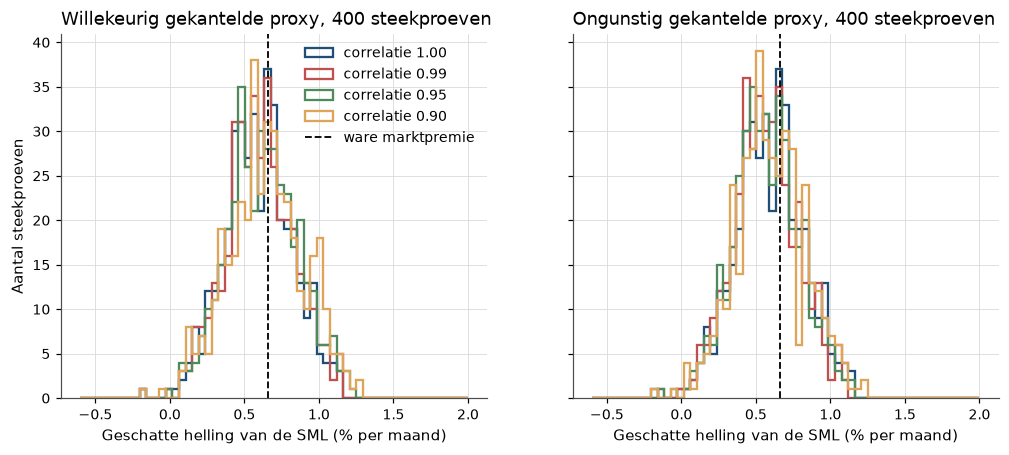

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
bins = np.linspace(-0.6, 2.0, 60)
for ax, kind in zip(axes, ["willekeurig", "ongunstig"]):
    for rho in rhos:
        subset = sims[(sims["kanteling"] == kind) & (sims["rho"] == rho)]
        ax.hist(100 * subset["helling"], bins=bins, histtype="step", lw=1.5,
                label=f"correlatie {rho:.2f}")
    ax.axvline(100 * premium_m, color="black", lw=1.2, ls="--", label="ware marktpremie")
    ax.set_xlabel("Geschatte helling van de SML (% per maand)")
    ax.set_title(f"{kind.capitalize()} gekantelde proxy, 400 steekproeven")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
plt.show()

:::{figure} #cel-roll-simulatie
:label: fig-roll-simulatie
:width: 100%

Verdeling van de geschatte SML-helling over 400 steekproeven van vijftig jaar, in
een wereld waarin het CAPM exact geldt. Links: proxy's die in een willekeurige
richting van de markt afwijken; de verdeling verandert nauwelijks met de
correlatie. Rechts: proxy's met dezelfde correlatie die in de ongunstige richting
afwijken. In beide panelen overstemt de steekproefruis, ongeveer
$\sigma_m/\sqrt{T}$, het verschil tussen de proxy's: uit de helling alleen ziet de
onderzoeker niet welke proxy hij heeft.
:::

De tabel is in procenten per maand, en de ware marktpremie is 0,66% per maand.
Kijk eerst naar de populatiekolommen. Een willekeurige kanteling verandert de
ware lijn nauwelijks: bij correlatie 0,90 is de helling 0,72% in plaats van 0,66%,
met een intercept van 0,08% per maand. De ongunstige kanteling met dezelfde
correlatie geeft een helling van 0,79% en een intercept van −0,34% per maand — ruim
4% per jaar aan negatieve "alfa" voor een activum met bèta nul, in een wereld waarin
het CAPM exact geldt. Bij correlatie 0,99, een proxy die 99% van de maximale
Sharpe-ratio haalt, is het ware intercept al −0,08% per maand.

Dan de steekproefkolommen, en hier komt motief 1 binnen. De 90%-band van de
geschatte helling loopt in elke rij van ongeveer 0,22% tot 1,0% per maand, een
breedte die de verschillen tussen de rijen volledig overstemt. Dat is geen toeval:
de helling is in wezen het gemiddelde rendement van een portefeuille met bèta één,
en de standaardfout daarvan is ongeveer $\sigma_m/\sqrt{T} = 4{,}69/\sqrt{600} = 0{,}19\%$
per maand. De mediaan ligt bovendien in alle rijen onder de populatiewaarde, tussen
0,56 en 0,64%: de attenuatie door geschatte bèta's uit [](#02-08-capm), omdat we op
individuele activa met veel eigen ruis schatten. Het intercept is scherper gemeten
(standaarddeviatie 0,14 tot 0,20% per maand), en daar is de ongunstige kanteling wél
zichtbaar: de mediaan daalt van +0,05% naar −0,11% per maand, terwijl zij bij een
willekeurige kanteling stijgt naar +0,14%.

Hoe weinig inefficiëntie is er nodig om de relatie helemaal weg te werken? Dat is
deel (b) van de simulatie, en daarvoor hebben we geen steekproeven nodig: de
propositie geeft het antwoord in de populatie. We lopen het pad
$\mathbf{w}_m - c\,\mathbf{d}$ af van $c = 0$ tot voorbij $c^{*}$, en vergelijken met
duizend willekeurige kantelingen met correlaties tussen 0,5 en 1.

In [6]:
path = []
c_star = (world["d"] @ world["cov"] @ world["w_m"]) / (world["d"] @ world["cov"] @ world["d"])
for c in np.linspace(0.0, 1.15 * c_star, 200):
    w = world["w_m"] - c * world["d"]
    _, slope, r2 = population_sml(world, w)
    path.append({"correlatie": corr_with_market(world, w), "helling / premie": slope / premium_m,
                 "R2": r2})
path = pd.DataFrame(path)

random_tilts = []
for _ in range(1000):
    e = rng.standard_normal(100)
    w = tilt_to_corr(world, e - e.mean(), rng.uniform(0.5, 1.0))
    random_tilts.append({"correlatie": corr_with_market(world, w),
                         "helling / premie": population_sml(world, w)[1] / premium_m})
random_tilts = pd.DataFrame(random_tilts)

sensitivity = {}
for n in [25, 100, 500]:
    other = world if n == 100 else make_world(n)
    sensitivity[f"N = {n}"] = {"rho*": np.sqrt(1 - corr_with_market(other, other["d"])**2)}
pd.DataFrame(sensitivity).T.round(3)

,rho*
N = 25,0.718
N = 100,0.623
N = 500,0.344


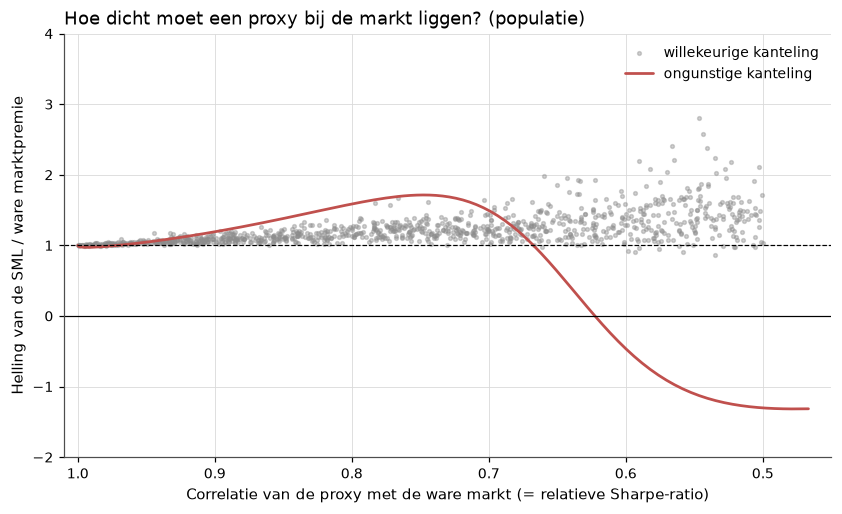

In [7]:
fig, ax = plt.subplots()
ax.scatter(random_tilts["correlatie"], random_tilts["helling / premie"], s=6, alpha=0.4,
           color=hap.plotting.COLORS[7], label="willekeurige kanteling")
ax.plot(path["correlatie"], path["helling / premie"], color=hap.plotting.COLORS[1],
        lw=1.8, label="ongunstige kanteling")
ax.axhline(1.0, color="black", lw=0.8, ls="--")
ax.axhline(0.0, color="black", lw=0.8)
ax.set_xlim(1.01, 0.45)
ax.set_ylim(-2, 4)
ax.set_xlabel("Correlatie van de proxy met de ware markt (= relatieve Sharpe-ratio)")
ax.set_ylabel("Helling van de SML / ware marktpremie")
ax.set_title("Hoe dicht moet een proxy bij de markt liggen? (populatie)")
ax.legend()
plt.show()

:::{figure} #cel-roll-pad
:label: fig-roll-pad
:width: 90%

De helling van de populatie-SML, als fractie van de ware marktpremie, tegen de
correlatie van de proxy met de ware markt. Willekeurige kantelingen (grijs) blijven
dicht bij één. De ongunstige kanteling (rood) laat de helling eerst stijgen en
daarna door nul zakken, terwijl de proxy nog steeds een groot deel van de
Sharpe-ratio van de markt haalt.
:::

In deze wereld heeft de beste proxy met helling nul een correlatie van 0,62 met de
ware markt: hij haalt 62% van haar Sharpe-ratio, en toch verklaart bèta ten opzichte
van hem niets van de cross-sectie. Het pad ernaartoe is niet monotoon. Tussen
correlatie 1 en ongeveer 0,8 wordt de lijn eerst steiler, tot bijna driemaal de
ware premie, en daarna valt de helling snel naar nul en verder naar negatieve
waarden. Hoe dicht de nulhelling bij de markt ligt, hangt af van de wereld: met 25
activa is $\rho^{*} = 0{,}72$, met 500 activa $0{,}34$. Dat past bij
[](#eq-roll-rhostar): $\rho^{*}$ is groot als het zero-cost-rendement $R_d$ vooral
idiosyncratische ruis is. Het punt van Roll en Ross is dus
niet dat elke proxy de lijn willekeurig maakt, maar dat correlatie met de markt —
de enige maat die een onderzoeker zou kunnen proberen te begrenzen — de lijn niet
vastlegt.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Richard Roll, *A Critique of the Asset Pricing Theory's Tests Part I: On
Past and Potential Testability of the Theory*, Journal of Financial Economics 1977
{cite}`Roll1977`; Richard Roll, *R²*, The Journal of Finance 1988 {cite}`Roll1988`.

**Wat.** (a) Rolls tautologie ({prf:ref}`thm-roll-roll`): tegenover de in-sample
tangentportefeuille liggen alle gemiddelde excess rendementen exact op een lijn door
de oorsprong, tegenover een marktindex niet. (b) De samenvatting van Roll 1988: een
gemiddelde gecorrigeerde $R^2$ van ongeveer 0,35 met maanddata en 0,20 met dagdata
voor grote aandelen, verklaard door markt, industrie en nieuws.

**Data hier.** (a) De 25 size/BM-portefeuilles van French, value-weighted,
1963-07 tot 2026-07, en de CRSP-marktindex en risicovrije rente uit
`hap.data.market_monthly()`. (b) Portefeuilles: dezelfde 25, de 49 en de 10
industrieportefeuilles van French (maandelijks). Aandelen: de vijftig grote
Amerikaanse aandelen uit [](#02-07-event-studies), dagelijkse gecorrigeerde
slotkoersen 2002-01 tot 2026-07 via `hap.data.yahoo(...)`; als markt de dagelijkse
en maandelijkse CRSP-index van French, als industrie de 10 industrieportefeuilles
(dagelijks en maandelijks) en de 49 industrieportefeuilles (maandelijks), elk aandeel
met de hand ingedeeld.

**Verschil met het origineel.** Roll gebruikte CRSP-aandelen, een eigen
industrie-indeling en een nieuwsvariabele uit de financiële pers; zijn precieze
steekproef hebben we niet in de primaire tekst kunnen verifiëren. Wij hebben geen
nieuwsdata, dus de nieuwsdag-analyse ontbreekt. Onze vijftig aandelen zijn geen
willekeurige steekproef: het zijn grote, overlevende ondernemingen met
aandelensplitsingen, zwaar in technologie, en de periode is 2002–2026. Ons
industrierendement bevat het aandeel zelf, wat de $R^2$ voor de allergrootste
bedrijven iets opdrijft; bij de 10 brede industrieën is dat effect klein. Het
weer-verhaal van Roll 1984 repliceren we niet: er zijn geen gratis dagkoersen van
sinaasappelsap-futures.

**Verwachte afwijking.** (a) Moet exact zijn: een $R^2$ van 1 en een intercept van
nul (tot op machineprecisie) voor de tangentportefeuille; voor de marktindex een
$R^2$ ver onder 1 en een helling die niet gelijk is aan de marktpremie. (b) De
$R^2$ van individuele aandelen moet ruim onder 50% liggen, zowel dagelijks als
maandelijks, en die van portefeuilles veel hoger; de industrie moet de $R^2$
verhogen. De orde van grootte van Roll (0,2–0,35) moet terugkomen. De rangorde
tussen dag- en maanddata is minder zeker: in een recente periode met vooral zeer
grote, liquide aandelen verwachten we minder van het dagelijkse
niet-synchrone-handelseffect dat Rolls dagcijfer drukte.
```

### De tautologie op de 25 size/BM-portefeuilles

We vergelijken vier proxy's: de in-sample tangentportefeuille van de 25
portefeuilles, de proxy met helling nul die volgens {prf:ref}`prop-roll-nulhelling`
het sterkst met die tangentportefeuille correleert (met de steekproefmomenten), de
gelijkgewogen portefeuille van de 25, en de CRSP-marktindex. Voor elk berekenen we
de bèta's van de 25 portefeuilles en de cross-sectionele lijn door hun gemiddelde
excess rendementen. De Fama-MacBeth- en GRS-toetsen op dezelfde data staan in
[](#02-08-capm) en [](#03-11-apt-no-arbitrage); die herhalen we niet.

In [8]:
market = hap_data.market_monthly()
ff25 = hap_data.french("25_Portfolios_5x5").sub(market["RF"], axis=0).loc["1963-07":].dropna()
mkt_excess = market["Mkt-RF"].loc[ff25.index]

mu_hat, Sigma_hat = ff25.mean().to_numpy(), ff25.cov().to_numpy()
w_tan = np.linalg.solve(Sigma_hat, mu_hat)
w_tan /= w_tan.sum()
d_hat = mu_hat - mu_hat.mean()
c_hat = (d_hat @ Sigma_hat @ w_tan) / (d_hat @ Sigma_hat @ d_hat)
w_zero = w_tan - c_hat * d_hat

proxies = {
    "in-sample tangent": ff25 @ w_tan,
    "helling nul, max. correlatie": ff25 @ w_zero,
    "gelijkgewogen 25": ff25.mean(axis=1),
    "CRSP-marktindex": mkt_excess,
}
tangent = proxies["in-sample tangent"]

tautology, fitted = {}, {}
for name, proxy in proxies.items():
    betas = ff25.apply(lambda col: col.cov(proxy) / proxy.var())
    intercept, slope, resid, r2 = sml_fit(betas.to_numpy(), mu_hat)
    fitted[name] = (betas, intercept, slope)
    tautology[name] = {
        "correlatie met tangent": proxy.corr(tangent),
        "Sharpe (p.j.)": np.sqrt(12) * proxy.mean() / proxy.std(),
        "gem. excess (% p.m.)": 100 * proxy.mean(),
        "SE gem. (% p.m.)": 100 * proxy.std() / np.sqrt(len(proxy)),
        "intercept (% p.m.)": 100 * intercept,
        "helling (% p.m.)": 100 * slope,
        "max |resid| (% p.m.)": 100 * np.abs(resid).max(),
        "R2": r2,
    }
print(f"{len(ff25)} maanden, {ff25.index[0]:%Y-%m} t/m {ff25.index[-1]:%Y-%m}; "
      f"som |gewichten| tangent = {np.abs(w_tan).sum():.2f}")
pd.DataFrame(tautology).T.round(4)

757 maanden, 1963-07 t/m 2026-07; som |gewichten| tangent = 13.81


,correlatie met tangent,Sharpe (p.j.),gem. excess (% p.m.),SE gem. (% p.m.),intercept (% p.m.),helling (% p.m.),max |resid| (% p.m.),R2
in-sample tangent,1.0000,1.3932,2.3386,0.2113,-0.0000,2.3386,0.0000,1.0000
"helling nul, max. correlatie",0.8853,1.2333,1.8328,0.1871,0.7624,-0.0000,0.4402,0.0000
gelijkgewogen 25,0.3658,0.5097,0.7624,0.1883,0.7120,0.0504,0.4582,0.0022
CRSP-marktindex,0.3449,0.4653,0.5992,0.1621,1.1641,-0.3698,0.3395,0.0811


De eerste rij is Rolls tautologie op echte data. Tegenover de in-sample
tangentportefeuille is het intercept nul, is de helling gelijk aan het gemiddelde
excess rendement van die portefeuille (2,34% per maand), en is de grootste afwijking
van de lijn nul tot op vier decimalen. Die portefeuille heeft een som van absolute
gewichten van 13,8 — een extreme long-short-positie die niemand houdt — en een
in-sample Sharpe-ratio van 1,39 per jaar die, zoals in [](#01-04-markowitz), buiten
de steekproef niet standhoudt ([](#ex-roll-3)). De CRSP-index geeft een helling van
−0,37% en een intercept van 1,16% per maand, met $R^2 = 0{,}08$: het vlakke-lijn-feit
van [](#02-08-capm).

De tweede rij is de Roll-Ross-proxy op echte data. Een portefeuille van de 25 met een
correlatie van 0,89 met de tangentportefeuille — en dus, volgens
{prf:ref}`lem-roll-sharpe` toegepast op de steekproefmomenten, 89% van haar
Sharpe-ratio (1,23 tegen 1,39 per jaar) — geeft een helling van precies nul. De
marktindex correleert maar 0,34 met de tangentportefeuille en haalt 0,47 per jaar.
Voor de index, die geen combinatie van de 25 is, geldt het lemma niet exact. Wat de tabel niet kan zeggen, is of dat komt doordat de
markt niet efficiënt is of doordat de CRSP-index de markt niet is. En het
gemiddelde excess marktrendement zelf is 0,60% per maand met een standaardfout van
0,16%, van dezelfde orde als de verschillen tussen de 25 gemiddelden.

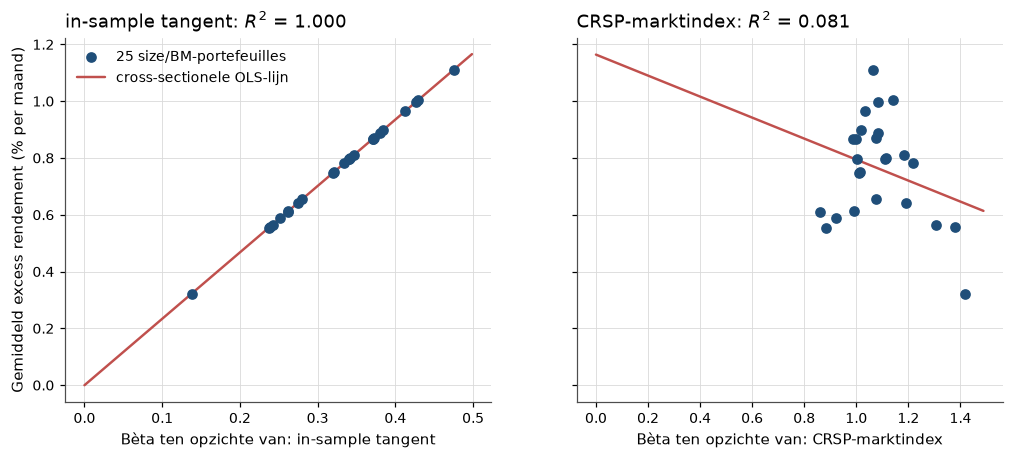

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, name in zip(axes, ["in-sample tangent", "CRSP-marktindex"]):
    betas, intercept, slope = fitted[name]
    grid = np.linspace(0, 1.05 * betas.max(), 20)
    ax.scatter(betas, 100 * mu_hat, color=hap.plotting.COLORS[0], zorder=3,
               label="25 size/BM-portefeuilles")
    ax.plot(grid, 100 * (intercept + slope * grid), color=hap.plotting.COLORS[1],
            label="cross-sectionele OLS-lijn")
    ax.set_xlabel(f"Bèta ten opzichte van: {name}")
    ax.set_title(f"{name}: $R^2$ = {tautology[name]['R2']:.3f}")
axes[0].set_ylabel("Gemiddeld excess rendement (% per maand)")
axes[0].legend(loc="upper left")
plt.show()

:::{figure} #cel-roll-tautologie
:label: fig-roll-tautologie
:width: 100%

Links: tegenover de achteraf efficiënte portefeuille liggen de 25 portefeuilles
exact op een lijn door de oorsprong — Rolls tautologie, niet een eigenschap van de
data. Rechts: tegenover de marktindex is er nauwelijks een lijn. De linkerfiguur
bewijst niets over het CAPM; de rechterfiguur verwerpt alleen de efficiëntie van
de index ten opzichte van deze 25 portefeuilles.
:::

### De $R^2$ van portefeuilles en aandelen

In [10]:
def adjusted_r2(frame):
    """Adjusted R^2 of the first column of `frame` on the remaining columns (with intercept)."""
    values = frame.dropna().to_numpy()
    y, X = values[:, 0], np.column_stack([np.ones(len(values)), values[:, 1:]])
    resid = y - X @ np.linalg.lstsq(X, y, rcond=None)[0]
    n, k = X.shape
    return 1 - (1 - (1 - resid.var() / y.var())) * (n - 1) / (n - k)


ind49 = hap_data.french("49_Industry_Portfolios")
ind10 = hap_data.french("10_Industry_Portfolios")
ind10_daily = hap_data.french("10_Industry_Portfolios", "daily")

portfolio_sets = {
    "25 size/BM": ff25,
    "49 industrieën": ind49.sub(market["RF"], axis=0).loc["1963-07":].dropna(axis=1),
    "10 industrieën": ind10.sub(market["RF"], axis=0).loc["1963-07":],
}
portfolio_r2 = {
    name: pd.Series({col: adjusted_r2(pd.concat([panel[col], mkt_excess], axis=1, join="inner"))
                     for col in panel.columns})
    for name, panel in portfolio_sets.items()
}
pd.DataFrame({name: {"aantal": len(r2), "gemiddelde R2": r2.mean(), "mediaan R2": r2.median(),
                     "minimum": r2.min(), "maximum": r2.max()}
              for name, r2 in portfolio_r2.items()}).T.round(3)

,aantal,gemiddelde R2,mediaan R2,minimum,maximum
25 size/BM,25.0,0.734,0.745,0.575,0.883
49 industrieën,47.0,0.535,0.553,0.059,0.813
10 industrieën,10.0,0.622,0.608,0.330,0.850


Nu de vijftig aandelen. De indeling in industrieën gebeurt met de hand, op basis
van de hoofdactiviteit; de keuze is bij een paar conglomeraten (Berkshire
Hathaway, Amphenol) discutabel, maar verandert de gemiddelden niet merkbaar.

In [11]:
INDUSTRY_49 = {
    "AAPL": "Hardw", "ADBE": "Softw", "AMZN": "Rtail", "ANET": "Hardw", "APH": "ElcEq",
    "AVGO": "Chips", "BAC": "Banks", "BRK-B": "Insur", "CMG": "Meals", "CPRT": "BusSv",
    "CRM": "Softw", "CSX": "Trans", "CTAS": "BusSv", "CVX": "Oil", "DE": "Mach",
    "DHR": "LabEq", "DXCM": "MedEq", "EW": "MedEq", "FAST": "Whlsl", "FTNT": "Softw",
    "GILD": "Drugs", "GOOGL": "Softw", "IDXX": "LabEq", "ISRG": "MedEq", "KO": "Soda",
    "LRCX": "Chips", "MA": "BusSv", "MNST": "Soda", "NFLX": "Fun", "NKE": "Clths",
    "NOW": "Softw", "NVDA": "Chips", "ODFL": "Trans", "ORLY": "Rtail", "PANW": "Softw",
    "PG": "Hshld", "QCOM": "Chips", "ROST": "Rtail", "SBUX": "Meals", "SHW": "Chems",
    "SMCI": "Hardw", "TJX": "Rtail", "TSCO": "Rtail", "TSLA": "Autos", "UNH": "Hlth",
    "UNP": "Trans", "V": "BusSv", "WFC": "Banks", "WMT": "Rtail", "WRB": "Insur",
}
INDUSTRY_10 = {
    "AAPL": "HiTec", "ADBE": "HiTec", "AMZN": "Shops", "ANET": "HiTec", "APH": "HiTec",
    "AVGO": "HiTec", "BAC": "Other", "BRK-B": "Other", "CMG": "Shops", "CPRT": "Shops",
    "CRM": "HiTec", "CSX": "Other", "CTAS": "Other", "CVX": "Enrgy", "DE": "Manuf",
    "DHR": "Hlth", "DXCM": "Hlth", "EW": "Hlth", "FAST": "Shops", "FTNT": "HiTec",
    "GILD": "Hlth", "GOOGL": "HiTec", "IDXX": "Hlth", "ISRG": "Hlth", "KO": "NoDur",
    "LRCX": "HiTec", "MA": "HiTec", "MNST": "NoDur", "NFLX": "HiTec", "NKE": "NoDur",
    "NOW": "HiTec", "NVDA": "HiTec", "ODFL": "Other", "ORLY": "Shops", "PANW": "HiTec",
    "PG": "NoDur", "QCOM": "HiTec", "ROST": "Shops", "SBUX": "Shops", "SHW": "Manuf",
    "SMCI": "HiTec", "TJX": "Shops", "TSCO": "Shops", "TSLA": "Durbl", "UNH": "Hlth",
    "UNP": "Other", "V": "HiTec", "WFC": "Other", "WMT": "Shops", "WRB": "Other",
}
tickers = sorted(INDUSTRY_49)
prices = hap_data.yahoo(tickers, start="2002-01-01", end="2026-08-01")
market_daily = hap_data.market_daily()

stock_daily = prices.pct_change(fill_method=None).loc["2002-01-03":"2026-07-31"]
stock_monthly = prices.resample("ME").last().pct_change(fill_method=None).loc["2002-02":"2026-07"]

rows = {}
for t in tickers:
    rows[t] = {
        "maand: markt": adjusted_r2(pd.concat(
            [stock_monthly[t], market["Mkt"]], axis=1, join="inner")),
        "maand: markt + 10 ind.": adjusted_r2(pd.concat(
            [stock_monthly[t], market["Mkt"], ind10[INDUSTRY_10[t]]], axis=1, join="inner")),
        "maand: markt + 49 ind.": adjusted_r2(pd.concat(
            [stock_monthly[t], market["Mkt"], ind49[INDUSTRY_49[t]]], axis=1, join="inner")),
        "dag: markt": adjusted_r2(pd.concat(
            [stock_daily[t], market_daily["Mkt"]], axis=1, join="inner")),
        "dag: markt + 10 ind.": adjusted_r2(pd.concat(
            [stock_daily[t], market_daily["Mkt"], ind10_daily[INDUSTRY_10[t]]], axis=1, join="inner")),
    }
stock_r2 = pd.DataFrame(rows).T

summary_r2 = stock_r2.agg(["mean", "median", "min", "max"]).T
summary_r2["SE gemiddelde"] = stock_r2.std() / np.sqrt(len(stock_r2))
summary_r2.columns = ["gemiddelde", "mediaan", "minimum", "maximum", "SE gemiddelde"]
summary_r2.round(3)

,gemiddelde,mediaan,minimum,maximum,SE gemiddelde
maand: markt,0.252,0.258,0.057,0.554,0.015
maand: markt + 10 ind.,0.349,0.334,0.075,0.812,0.022
maand: markt + 49 ind.,0.400,0.357,0.147,0.872,0.025
dag: markt,0.328,0.332,0.126,0.504,0.013
dag: markt + 10 ind.,0.411,0.408,0.148,0.833,0.020


De tabel bevestigt het beeld van Roll, met één verschil in rangorde. Maandelijks
verklaart de markt gemiddeld 25% van de variantie van een aandeel, markt en brede
industrie samen 35%, en markt en de fijnere indeling in 49 industrieën 40%. Dagelijks
is het 33% met de markt alleen en 41% met de industrie erbij, ruim boven Rolls 0,20.
De standaardfouten van de gemiddelden over aandelen liggen rond 0,02: ook met vijftig
aandelen is de $R^2$ scherp gemeten, anders dan elk gemiddeld rendement in deze
lecture. Dat onze dag-$R^2$ boven onze maand-$R^2$ ligt, terwijl het bij Roll omgekeerd
was, past bij de steekproef. Onze aandelen behoren tot de meest verhandelde ter
wereld, zodat *niet-synchrone handel* (slotkoersen van verschillende momenten, wat
dagelijkse covarianties drukt) nauwelijks speelt, en de periode bevat meerdere
crisisjaren waarin aandelen sterker samen bewegen ([](#ex-roll-2)).

Voor portefeuilles is de $R^2$ op de markt alleen al 0,54 (49 industrieën), 0,62 (10
industrieën) en 0,73 (25 size/BM): spreiding over honderden aandelen haalt het
bedrijfsspecifieke deel weg, en wat overblijft is marktbeweging. Wat we níet kunnen repliceren, is Rolls tweede vondst, dat het
weglaten van nieuwsdagen de $R^2$ nauwelijks verhoogt: daarvoor zijn datums van
bedrijfsnieuws nodig die niet in `hap.data` zitten.

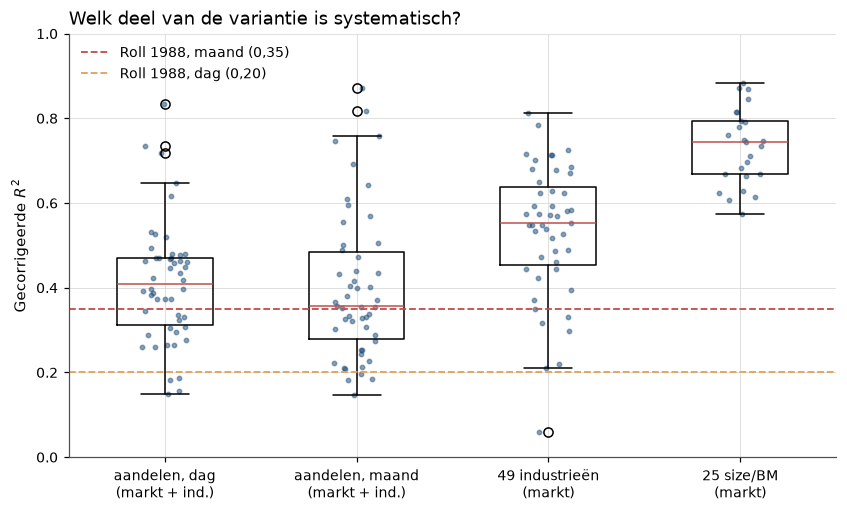

In [12]:
fig, ax = plt.subplots()
groups = {
    "aandelen, dag\n(markt + ind.)": stock_r2["dag: markt + 10 ind."],
    "aandelen, maand\n(markt + ind.)": stock_r2["maand: markt + 49 ind."],
    "49 industrieën\n(markt)": portfolio_r2["49 industrieën"],
    "25 size/BM\n(markt)": portfolio_r2["25 size/BM"],
}
ax.boxplot(list(groups.values()), tick_labels=list(groups.keys()), widths=0.5)
for x, values in enumerate(groups.values(), start=1):
    ax.scatter(np.full(len(values), x) + rng.uniform(-0.12, 0.12, len(values)), values,
               s=8, alpha=0.5, color=hap.plotting.COLORS[0])
ax.axhline(0.35, color=hap.plotting.COLORS[1], ls="--", lw=1.2, label="Roll 1988, maand (0,35)")
ax.axhline(0.20, color=hap.plotting.COLORS[3], ls="--", lw=1.2, label="Roll 1988, dag (0,20)")
ax.set_ylim(0, 1)
ax.set_ylabel("Gecorrigeerde $R^2$")
ax.set_xlabel("")
ax.set_title("Welk deel van de variantie is systematisch?")
ax.legend(loc="upper left")
plt.show()

:::{figure} #cel-roll-r2
:label: fig-roll-r2
:width: 90%

Gecorrigeerde $R^2$ van regressies op markt (en industrie) voor individuele
aandelen en voor portefeuilles. Bij aandelen is het grootste deel van de variantie
bedrijfsspecifiek; bij portefeuilles is het wegdiversifieerd. De stippellijnen zijn
de gemiddelden uit de samenvatting van {cite:t}`Roll1988`.
:::

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Roll maakte niet het CAPM kapot, maar een manier van
lezen. Zijn stelling is een van de schoonste resultaten in het vak: een lineaire
relatie tussen verwacht rendement en bèta is niets meer en niets minder dan
efficiëntie van de gekozen portefeuille, en dat geldt in de populatie én in elke
steekproef. De $R^2$-analyse van 1988 is even robuust: ze vraagt alleen om
varianties, en die zijn goed te meten. Wat we op vijftig aandelen van 2002–2026
vinden, ligt in dezelfde orde van grootte als wat Roll vond voor een heel andere
steekproef.

**Waar het breekt.** Op de 25 size/BM-portefeuilles geeft de achteraf efficiënte
portefeuille een $R^2$ van precies 1 en de CRSP-index een $R^2$ van 0,08; de
data kunnen niet zeggen of dat komt doordat het CAPM onjuist is of doordat de index
niet de markt is. Tegelijk verklaren markt en industrie samen maar ongeveer
35 tot 40% van de maandelijkse variantie van grote Amerikaanse aandelen. Het
CAPM als theorie met toetsen heeft daarmee een centrale grootheid die niet
waarneembaar is; wat overblijft is een feit — de lijn is vlak voor elke waarneembare
proxy — dat op een verklaring wacht.

**Risico of vergissing?** Beide feiten hebben twee lezingen. Voor de vlakke lijn
zegt de Chicago-lezing dat de index de verkeerde portefeuille is: tel menselijk
kapitaal en tijdvariatie in de premie mee, zoals {cite:t}`JagannathanWang1996`
deden, en een groter deel van de cross-sectie is beloning voor risico. De
Yale-lezing zegt dat geen enkele redelijke proxy de lijn herstelt, en dat
{cite:t}`Shanken1987` precies dat liet zien: als het CAPM geldt, moet de ware markt
opvallend weinig op aandelen en obligaties lijken. Voor de lage $R^2$ zegt de eerste
lezing dat bedrijfsspecifieke beweging informatie is die via handel in de prijs
komt — {cite:t}`MorckYeungYu2000` lezen een lage $R^2$ als teken van
informatieve prijzen, en {cite:t}`BoudoukhRichardsonShenWhitelaw2007` lieten zien dat
het weer de sinaasappelsapprijs wél sterk beweegt op de weinige dagen dat vorst
dreigt. De tweede lezing ziet in dezelfde onverklaarbare volatiliteit ruis, en
Roll zelf liet de mogelijkheid van beweging zonder concrete aanleiding open. De data
die de lezingen zouden scheiden — het rendement van de ware markt, of een volledige
registratie van alle private informatie — bestaan niet.

**Wat er daarna kwam.** Als individuele koersen meer bewegen dan nieuws kan
verklaren, is de volgende vraag of dat ook geldt voor de markt als geheel, en dat is
het werk van Shiller en LeRoy en Porter in [](#03-15-shiller-excess-volatility).

## Oefeningen

:::{exercise}
:label: ex-roll-1

**De ongunstige proxy in het toy-voorbeeld.** Voeg aan de drie activa een
risicovrije rente van 2% toe, zodat de tangentportefeuille
$\mathbf{w}_m = (\tfrac13, \tfrac29, \tfrac49)$ is, met excess rendementen
$\boldsymbol{\mu}^{e} = (0{,}08;\ 0{,}12;\ 0{,}02)$.

1. Bereken $\mathbf{d}$, $\Cov(R_m, R_d)$, $\Var(R_d)$, $c^{*}$ en $\rho^{*}$ uit
   {prf:ref}`prop-roll-nulhelling`, met de hand.
2. Bereken de gewichten van $\mathbf{w}^{*}$ en controleer numeriek dat de
   OLS-helling van $\mu^{e}_i$ op $\beta_{i,w^{*}}$ nul is en dat
   $S_{w^{*}}/S_m = \rho^{*}$.
3. Wat is het intercept van die lijn, en waarom?
:::

:::{solution} ex-roll-1
:class: dropdown

**(1)** $\bar\mu^{e} = 0{,}07333$, dus $\mathbf{d} = (0{,}006667;\ 0{,}046667;\ -0{,}053333)$
en $\boldsymbol{\Sigma}\mathbf{d} = (0{,}0012;\ 0{,}004333;\ -0{,}000533)$. Dan
$\Var(R_d) = \mathbf{d}'\boldsymbol{\Sigma}\mathbf{d} = 0{,}00023867$,
$\Cov(R_m, R_d) = \mathbf{w}_m'\boldsymbol{\Sigma}\mathbf{d} = 0{,}0011259$ en
$\sigma_m^2 = 28/2025 = 0{,}013827$. Dus
$\Corr(R_m,R_d)^2 = 0{,}0011259^2/(0{,}013827 \cdot 0{,}00023867) = 0{,}3841$,
$\rho^{*} = \sqrt{0{,}6159} = 0{,}785$ en $c^{*} = 0{,}0011259/0{,}00023867 = 4{,}718$.

**(2) en (3)**

In [13]:
mu_e_toy = mu - 0.02
w_m_toy = np.array([1 / 3, 2 / 9, 4 / 9])
d_toy = mu_e_toy - mu_e_toy.mean()
cov_md, var_d = w_m_toy @ Sigma @ d_toy, d_toy @ Sigma @ d_toy
var_m_toy = w_m_toy @ Sigma @ w_m_toy
c_toy = cov_md / var_d
w_star = w_m_toy - c_toy * d_toy
intercept_star, slope_star, _, _ = sml_fit(Sigma @ w_star / (w_star @ Sigma @ w_star), mu_e_toy)

pd.Series({
    "Var(R_d)": var_d, "Cov(R_m, R_d)": cov_md, "c*": c_toy,
    "rho*": np.sqrt(1 - cov_md**2 / (var_m_toy * var_d)),
    "w*_A": w_star[0], "w*_B": w_star[1], "w*_C": w_star[2], "som w*": w_star.sum(),
    "OLS-helling": slope_star, "intercept": intercept_star,
    "gemiddeld mu^e": mu_e_toy.mean(),
    "S_w* / S_m": (w_star @ mu_e_toy / np.sqrt(w_star @ Sigma @ w_star))
                  / (w_m_toy @ mu_e_toy / np.sqrt(var_m_toy)),
}).round(6)

Var(R_d)          0.000239
Cov(R_m, R_d)     0.001126
c*                4.717567
rho*              0.784764
w*_A              0.301883
w*_B              0.002069
w*_C              0.696048
som w*            1.000000
OLS-helling      -0.000000
intercept         0.073333
gemiddeld mu^e    0.073333
S_w* / S_m        0.784764
dtype: float64

De proxy $\mathbf{w}^{*}$ heeft gewichten $(0{,}302;\ 0{,}002;\ 0{,}696)$: bijna al het gewicht van B, het
activum met de hoogste premie, is naar C verschoven. De helling is nul en de
Sharpe-ratio is 78,5% van die van de markt. Het intercept is het gemiddelde
verwachte excess rendement $0{,}07333$, want een OLS-lijn met helling nul gaat door
het gemiddelde. De oefening laat zien dat de "vlakste mogelijke" SML hoort bij een
proxy die ruim driekwart van de maximale Sharpe-ratio haalt — met drie activa.
:::

:::{exercise}
:label: ex-roll-2

**Wanneer is de $R^2$ hoog?** Gebruik de dagrendementen van de vijftig aandelen en
de dagelijkse marktindex.

1. Bereken per kalenderjaar 2002–2025 de gemiddelde gecorrigeerde $R^2$ over de
   aandelen van een regressie op de markt (alleen jaren met minstens 200
   waarnemingen per aandeel).
2. In welke jaren is de $R^2$ het hoogst en het laagst? Wat hebben de hoogste jaren
   gemeen?
3. Wat betekent dat voor de lezing van $1 - R^2$ als "bedrijfsspecifieke
   informatie"?
:::

:::{solution} ex-roll-2
:class: dropdown

In [14]:
yearly = {}
for year in range(2002, 2026):
    daily = stock_daily.loc[str(year)]
    mkt_year = market_daily["Mkt"].loc[str(year)]
    values = [adjusted_r2(pd.concat([daily[t], mkt_year], axis=1, join="inner"))
              for t in tickers if daily[t].notna().sum() >= 200]
    yearly[year] = {"gemiddelde R2": np.mean(values), "aantal aandelen": len(values),
                    "marktvolatiliteit (% p.j.)": 100 * np.sqrt(252) * mkt_year.std()}
yearly = pd.DataFrame(yearly).T
yearly.round(3)

,gemiddelde R2,aantal aandelen,marktvolatiliteit (% p.j.)
2002,0.298,36.0,25.237
2003,0.286,37.0,16.669
2004,0.243,37.0,11.436
2005,0.237,39.0,10.527
2006,0.230,41.0,10.642
2007,0.312,42.0,15.751
2008,0.477,43.0,40.007
2009,0.399,44.0,27.279
2010,0.397,46.0,18.496
2011,0.514,47.0,24.215


In [15]:
pd.Series({
    "hoogste jaar": int(yearly["gemiddelde R2"].idxmax()),
    "laagste jaar": int(yearly["gemiddelde R2"].idxmin()),
    "correlatie R2 met marktvolatiliteit": yearly["gemiddelde R2"].corr(
        yearly["marktvolatiliteit (% p.j.)"]),
}).round(3)

hoogste jaar                           2020.000
laagste jaar                           2017.000
correlatie R2 met marktvolatiliteit       0.815
dtype: float64

**(1) en (2)** De gemiddelde $R^2$ loopt van 0,15 in 2017 tot 0,56 in 2020. De
hoogste jaren zijn 2020 (0,56), 2011 (0,51), 2022 (0,48) en 2008 (0,48): allemaal
jaren van marktbrede onrust, met een marktvolatiliteit van 24 tot 40% per jaar. Over
de 24 jaren is de correlatie tussen de gemiddelde $R^2$ en de marktvolatiliteit 0,82.

**(3)** De $R^2$ is een verhouding,
$\beta_{i,m}^2\sigma_m^2/(\beta_{i,m}^2\sigma_m^2 + \sigma_{\varepsilon,i}^2)$. Stijgt de
marktvariantie terwijl de bedrijfsspecifieke variantie gelijk blijft, dan stijgt de
$R^2$ zonder dat er iets verandert aan hoeveel bedrijfsspecifieke informatie in de prijs
komt. Wie $1 - R^2$ leest als maat voor informatie, zoals {cite:t}`MorckYeungYu2000`,
moet dus rekening houden met het niveau van de marktvolatiliteit; anders zegt een
vergelijking tussen periodes of landen vooral iets over de noemer.
:::

:::{exercise}
:label: ex-roll-3

**De tautologie buiten de steekproef.** Schat de tangentportefeuille van de 25
size/BM-portefeuilles op 1963-07 t/m 1994-12 en houd de gewichten vast.

1. Bereken over 1995-01 t/m 2026-07 de bèta's van de 25 portefeuilles ten opzichte
   van die vaste portefeuille, en de cross-sectionele OLS-lijn door hun gemiddelde
   excess rendementen: intercept, helling en $R^2$.
2. Vergelijk met de CRSP-index over dezelfde periode, en met de in-sample
   tangentportefeuille van 1995–2026.
3. Wat blijft er van de perfecte lijn over, en wat zegt dat over Rolls
   tautologie?
:::

:::{solution} ex-roll-3
:class: dropdown

In [16]:
first, second = ff25.loc[:"1994-12"], ff25.loc["1995-01":]
w_first = np.linalg.solve(first.cov().to_numpy(), first.mean().to_numpy())
w_first /= w_first.sum()
w_second = np.linalg.solve(second.cov().to_numpy(), second.mean().to_numpy())
w_second /= w_second.sum()

oos = {}
for name, proxy in {"tangent 1963-1994, vast": second @ w_first,
                    "tangent 1995-2026, in-sample": second @ w_second,
                    "CRSP-marktindex": mkt_excess.loc[second.index]}.items():
    betas = second.apply(lambda col: col.cov(proxy) / proxy.var())
    intercept, slope, _, r2 = sml_fit(betas.to_numpy(), second.mean().to_numpy())
    oos[name] = {"intercept (% p.m.)": 100 * intercept, "helling (% p.m.)": 100 * slope,
                 "gem. excess proxy (% p.m.)": 100 * proxy.mean(), "R2": r2,
                 "Sharpe (p.j.)": np.sqrt(12) * proxy.mean() / proxy.std()}
pd.DataFrame(oos).T.round(3)

,intercept (% p.m.),helling (% p.m.),gem. excess proxy (% p.m.),R2,Sharpe (p.j.)
"tangent 1963-1994, vast",0.743,0.976,2.547,0.367,0.878
"tangent 1995-2026, in-sample",-0.000,2.624,2.624,1.000,1.702
CRSP-marktindex,1.274,-0.363,0.798,0.111,0.616


**(1) en (2)** Met de gewichten van 1963–1994 vast verklaren de bèta's over
1995–2026 nog 37% van de spreiding in gemiddelde rendementen, met een intercept van
0,74% per maand en een helling van 0,98%, tegen een gemiddeld excess rendement van die
portefeuille van 2,55%. De lijn gaat dus niet meer door de oorsprong en is veel te
vlak: buiten de steekproef is de portefeuille niet efficiënt. De in-sample
tangentportefeuille van 1995–2026 geeft opnieuw exact $R^2 = 1$ met intercept nul, en de
CRSP-index $R^2 = 0{,}11$ met een negatieve helling.

**(3)** De perfecte lijn is een eigenschap van de steekproef waarin de portefeuille is
gekozen. Dat de vaste portefeuille buiten de steekproef nog een Sharpe-ratio van 0,88
per jaar haalt tegen 0,62 voor de index, wijst op een blijvende richting van small en
value — het feit waarmee [](#04-18-fama-french) begint — maar een toets van een
theorie is het niet.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->